# Lorenz '96 — High-Dimensional Chaos

The [Lorenz '96 system](https://en.wikipedia.org/wiki/Lorenz_96_model) is a
periodic 1D lattice of $N$ coupled variables driven by a constant forcing
$F$. It is a workhorse model for testing data assimilation and ensemble
forecasting methods.

**What you'll learn:**

1. How to set up and run a high-dimensional chaotic ODE in somax
2. How the Hovmoller diagram reveals wave-like propagation
3. How forcing strength $F$ controls the transition to chaos
4. How to compute gradients and run ensembles at scale

## Background

The system consists of $N$ variables $X_k$ on a periodic ring:

$$
\frac{dX_k}{dt}
= \underbrace{(X_{k+1} - X_{k-2})\, X_{k-1}}_{\text{advection}}
  - X_k + F
\qquad k = 1, \ldots, N
$$

with periodic boundary conditions $X_{k+N} = X_k$.

- The quadratic term mimics nonlinear advection (energy-conserving).
- The linear damping $-X_k$ dissipates energy.
- The constant forcing $F$ injects energy.

At $F = 8$ the system is fully chaotic with a doubling time of
approximately 0.42 time units (about 2.1 days if one time unit
equals 5 days).

In [1]:
from __future__ import annotations

import diffrax as dfx
import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jrandom
import matplotlib.pyplot as plt

from somax.models import L96State, Lorenz96

## 1. Create the model

We use $N = 40$ variables (Lorenz's original choice) with the
standard chaotic forcing $F = 8$.

In [2]:
N = 40
model = Lorenz96.create(F=8.0)
print(model)

Lorenz96(params=L96Params(F=weak_f32[]))


## 2. Forward simulation

The initial condition is a small perturbation of the $F$-equilibrium
state $X_k = F$ for all $k$. This is an unstable fixed point of the
system — the perturbation grows and the trajectory settles onto the
chaotic attractor.

In [3]:
state0 = L96State.init_state(ndim=N, noise=0.01, F=8.0)

t0, t1, dt = 0.0, 20.0, 0.01
ts = jnp.arange(t0, t1, dt)

sol = model.integrate(
    state0,
    t0=t0,
    t1=t1,
    dt=dt,
    saveat=dfx.SaveAt(ts=ts),
)

print(f"Trajectory shape: {sol.ys.x.shape}")  # (T, N)

Trajectory shape: (2000, 40)


## 3. Hovmoller diagram

A Hovmoller plot shows the state as a function of position (x-axis)
and time (y-axis). The tilted bands reveal wave-like structures
propagating around the periodic ring.

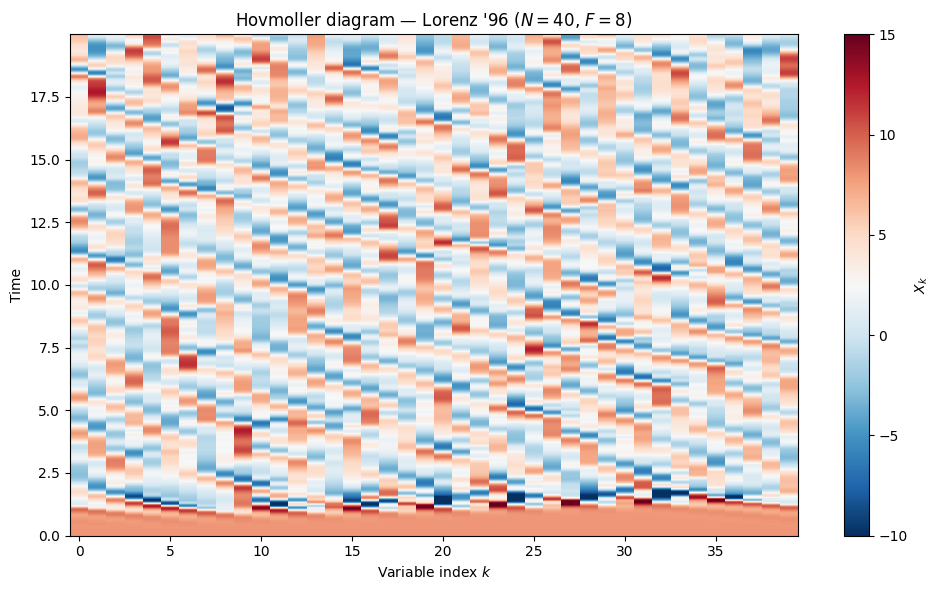

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.pcolormesh(
    jnp.arange(N),
    ts,
    sol.ys.x,
    cmap="RdBu_r",
    shading="auto",
    vmin=-10,
    vmax=15,
)
ax.set_xlabel("Variable index $k$")
ax.set_ylabel("Time")
ax.set_title(f"Hovmoller diagram — Lorenz '96 ($N={N}$, $F=8$)")
plt.colorbar(im, ax=ax, label="$X_k$")
plt.tight_layout()
plt.show()

## 4. Time series and statistics

Individual variables look like noisy oscillations. The climatological
mean is close to $F$ and the variance grows with forcing strength.

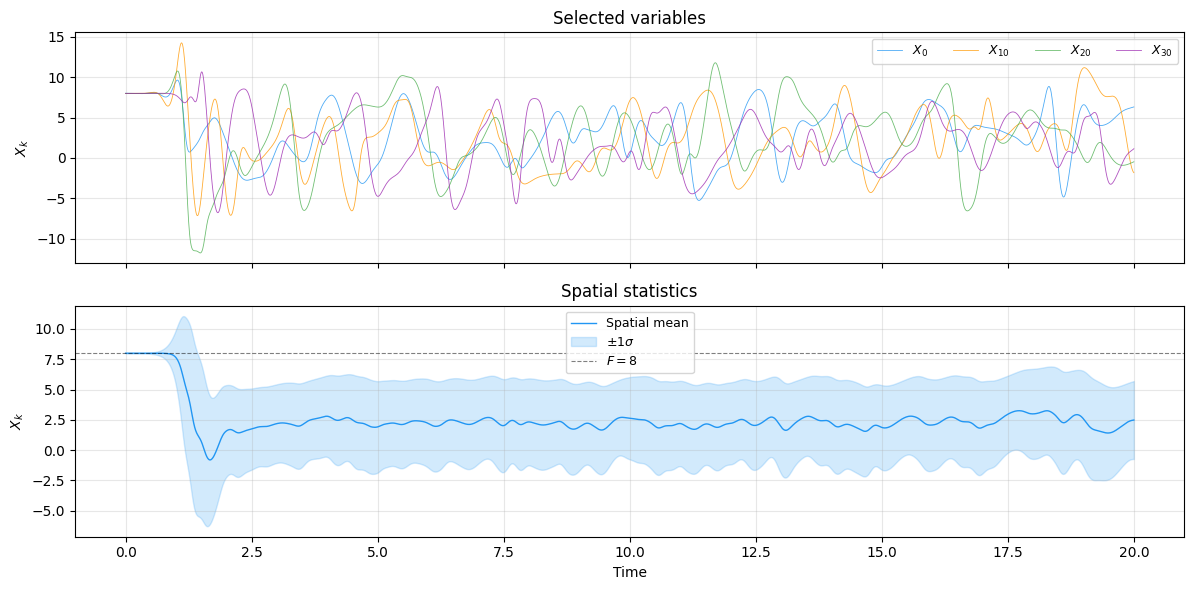

In [5]:
colors = ["#2196F3", "#FF9800", "#4CAF50", "#9C27B0", "#F44336"]

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

# Top: a few selected variables
ax = axes[0]
for i, c in zip([0, 10, 20, 30], colors, strict=False):
    ax.plot(ts, sol.ys.x[:, i], lw=0.6, alpha=0.8, color=c, label=f"$X_{{{i}}}$")
ax.set_ylabel("$X_k$")
ax.set_title("Selected variables")
ax.legend(fontsize=9, ncol=4)
ax.grid(True, alpha=0.3)

# Bottom: spatial mean and std
spatial_mean = jnp.mean(sol.ys.x, axis=1)
spatial_std = jnp.std(sol.ys.x, axis=1)
ax = axes[1]
ax.plot(ts, spatial_mean, lw=1, color="#2196F3", label="Spatial mean")
ax.fill_between(
    ts,
    spatial_mean - spatial_std,
    spatial_mean + spatial_std,
    alpha=0.2,
    color="#2196F3",
    label=r"$\pm 1\sigma$",
)
ax.axhline(8.0, color="k", ls="--", lw=0.8, alpha=0.5, label="$F = 8$")
ax.set_xlabel("Time")
ax.set_ylabel("$X_k$")
ax.set_title("Spatial statistics")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Diagnostics

`model.diagnose()` returns the total energy
$E = \tfrac{1}{2} \sum_k X_k^2$ and the spatial mean.

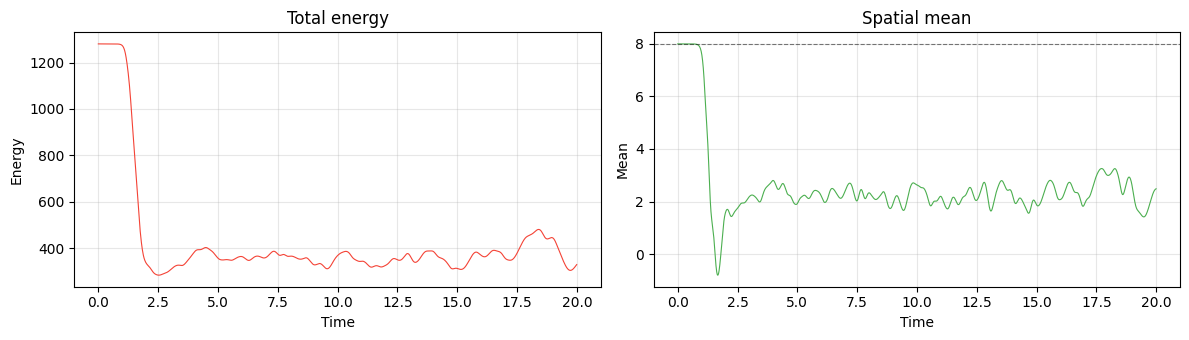

In [6]:
diags = jax.vmap(model.diagnose)(sol.ys)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

axes[0].plot(ts, diags.energy, lw=0.8, color="#F44336")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Energy")
axes[0].set_title("Total energy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(ts, diags.mean, lw=0.8, color="#4CAF50")
axes[1].axhline(8.0, color="k", ls="--", lw=0.8, alpha=0.5)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Mean")
axes[1].set_title("Spatial mean")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Forcing regimes

The Lorenz '96 system transitions from steady state to periodic
to chaotic as $F$ increases. We compare three regimes.

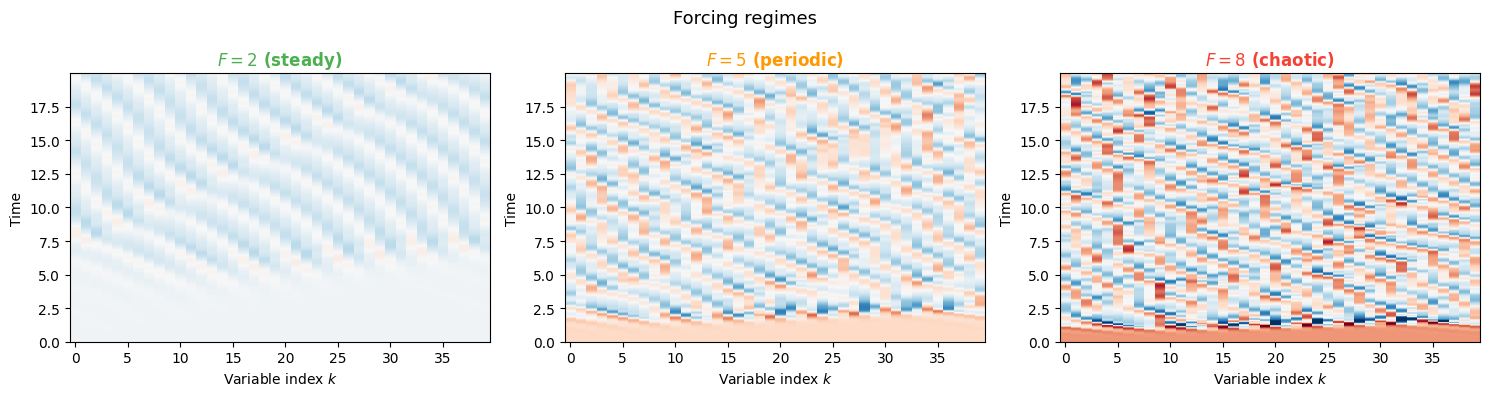

In [7]:
F_values = [2.0, 5.0, 8.0]
regime_labels = ["$F=2$ (steady)", "$F=5$ (periodic)", "$F=8$ (chaotic)"]
regime_colors = ["#4CAF50", "#FF9800", "#F44336"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, F_val, label, color in zip(
    axes, F_values, regime_labels, regime_colors, strict=True
):
    m = Lorenz96.create(F=F_val)
    s0 = L96State.init_state(ndim=N, noise=0.01, F=F_val)
    s = m.integrate(s0, t0=0.0, t1=20.0, dt=0.01, saveat=dfx.SaveAt(ts=ts))
    ax.pcolormesh(
        jnp.arange(N), ts, s.ys.x, cmap="RdBu_r", shading="auto", vmin=-10, vmax=15
    )
    ax.set_xlabel("Variable index $k$")
    ax.set_ylabel("Time")
    ax.set_title(label, color=color, fontweight="bold")

plt.suptitle("Forcing regimes", fontsize=13)
plt.tight_layout()
plt.show()

## 7. Sensitivity via `jax.grad`

We differentiate a short-horizon loss with respect to the forcing
parameter $F$. This is useful for parameter estimation and optimal
control.

In [8]:
state0_grad = L96State.init_state(ndim=N, noise=0.01, F=8.0)


@eqx.filter_grad
def compute_grad(model):
    sol = model.integrate(state0_grad, t0=0.0, t1=1.0, dt=0.01)
    return jnp.sum(sol.ys.x**2)


grads = compute_grad(model)
print(f"dL/dF = {grads.params.F:.4f}")

dL/dF = 394.0197


## 8. Ensemble forecast divergence

We launch 30 ensemble members from perturbed initial conditions
and measure the ensemble spread over time — the hallmark of
deterministic chaos.

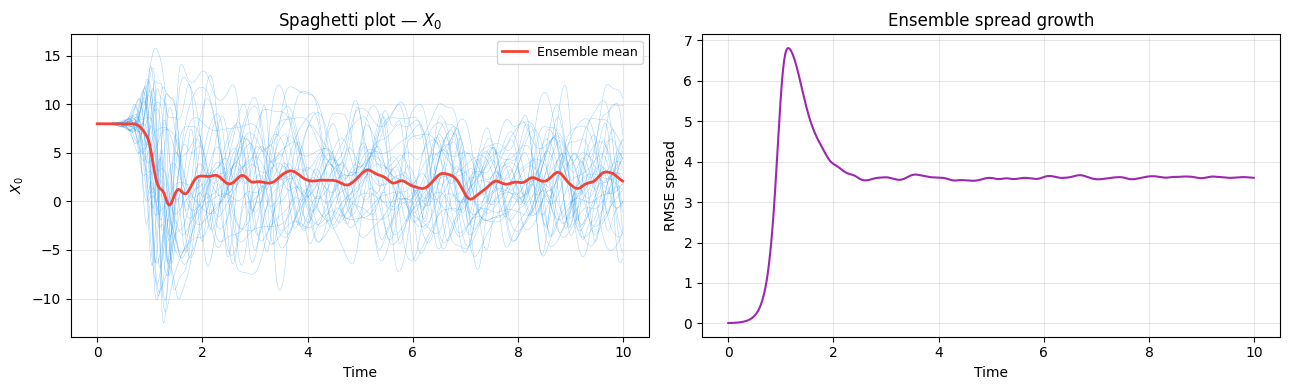

In [9]:
n_ensemble = 30
key = jrandom.PRNGKey(0)
perturb = 0.01 * jrandom.normal(key, shape=(n_ensemble, N))
x0_base = 8.0 * jnp.ones(N)
ensemble_states = L96State(x=x0_base[None, :] + perturb)

ts_ens = jnp.arange(0.0, 10.0, 0.01)


def integrate_one(state0):
    return model.integrate(
        state0,
        t0=0.0,
        t1=10.0,
        dt=0.01,
        saveat=dfx.SaveAt(ts=ts_ens),
    )


ensemble_sol = eqx.filter_vmap(integrate_one)(ensemble_states)

# Compute ensemble spread (RMSE relative to ensemble mean)
ens_mean = jnp.mean(ensemble_sol.ys.x, axis=0)  # (T, N)
spread = jnp.sqrt(
    jnp.mean((ensemble_sol.ys.x - ens_mean[None, :, :]) ** 2, axis=(0, 2))
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: spaghetti plot for variable 0
ax = axes[0]
for j in range(n_ensemble):
    ax.plot(ts_ens, ensemble_sol.ys.x[j, :, 0], lw=0.3, alpha=0.5, color="#2196F3")
ax.plot(ts_ens, ens_mean[:, 0], lw=2, color="#F44336", label="Ensemble mean")
ax.set_xlabel("Time")
ax.set_ylabel("$X_0$")
ax.set_title("Spaghetti plot — $X_0$")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: ensemble spread
ax = axes[1]
ax.plot(ts_ens, spread, lw=1.5, color="#9C27B0")
ax.set_xlabel("Time")
ax.set_ylabel("RMSE spread")
ax.set_title("Ensemble spread growth")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

| Concept | somax API |
|---------|-----------|
| Create a model | `Lorenz96.create(F=8.0)` |
| Initial condition | `L96State.init_state(ndim=40, F=8.0)` |
| Forward simulation | `model.integrate(state0, t0, t1, dt, saveat=...)` |
| Diagnostics | `model.diagnose(state)` — energy, mean |
| Gradients | `eqx.filter_grad(loss)(model)` — dL/dF |
| Ensemble | `eqx.filter_vmap(integrate_one)(batch_states)` |

**Key takeaways:**

- $F = 8$ produces fully developed chaos with a doubling time of
  ~0.42 time units
- The Hovmoller diagram reveals eastward-propagating wave packets
- Ensemble spread saturates after ~4 time units (the predictability
  horizon)